# CMSE 202 - Pneumonia Classification Using Traditional Machine Learning

## Model comparison and accuracy analysis

In [6]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive/')

## Loading data and splitting it

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC

from sklearn.datasets import load_files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.exceptions import ConvergenceWarning
from sklearn.base import clone

from sklearn.metrics import classification_report, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
import os
import pickle
import time

In [8]:
# Setup the directory paths
if IN_COLAB:
    base_folder = os.path.join("drive", "MyDrive", "colab")
else:
    base_folder = os.path.join("..", "..")
    
data_folder = os.path.join(base_folder, "data", "processed", "binary")

train_folder = os.path.join(data_folder, "train")
test_folder = os.path.join(data_folder, "test")

model_folder = os.path.join(base_folder, "models", "pneumonia_classifier")

os.makedirs(model_folder, exist_ok=True)

print(f"Train folder: {train_folder}")
print(f"Test folder: {test_folder}")

Train folder: ..\..\data\processed\binary\train
Test folder: ..\..\data\processed\binary\test


In [9]:
# Load in the images
train_dataset = load_files(train_folder, load_content=False)
test_dataset = load_files(test_folder, load_content=False)

X_train = []
X_test = []
y_train = train_dataset.target
y_test = test_dataset.target
categories = train_dataset.target_names

image_size = 128
grayscale = True

# Resize/grayscale the images and add them to respective arrays
for filename in train_dataset.filenames:
    try:
        img = img = Image.open(filename).convert("L" if grayscale else "RGB").resize((image_size, image_size))
        img_array = np.array(img).flatten()
        X_train.append(img_array)
    except Exception as e:
        print(f"Error loading image: {filename} - {e}")

for filename in test_dataset.filenames:
    try:
        img = img = Image.open(filename).convert("L" if grayscale else "RGB").resize((image_size, image_size))
        img_array = np.array(img).flatten()
        X_test.append(img_array)
    except Exception as e:
        print(f"Error loading image: {filename} - {e}")

X_train = np.array(X_train)
X_test = np.array(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (2000, 16384), Test shape: (500, 16384)


## Visualizing dataset

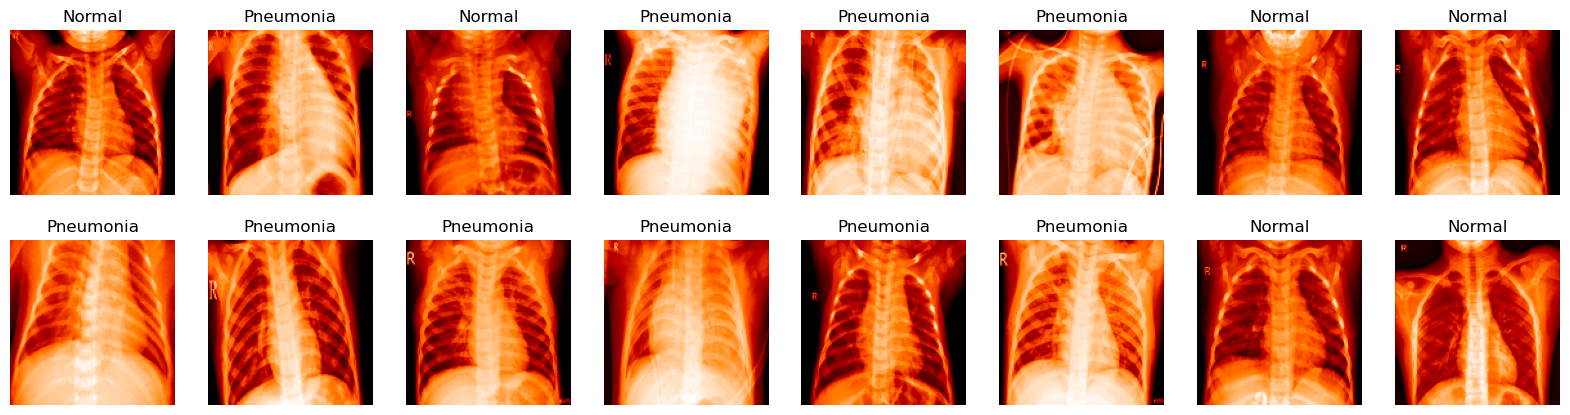

In [10]:
plt.figure(figsize=(20,5))
for n , i in enumerate(np.random.randint(0,len(X_train),16)):
    plt.subplot(2,8,n+1)
    plt.imshow(X_train[i].reshape(128, 128), cmap='gist_heat')
    plt.axis('off')
    plt.title(categories[y_train[i]])

## Feature Reduction

In [11]:
# Scaled vectors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA to preserve 95% variance in the data
variance = 0.95

pca = PCA(n_components=variance)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]} capturing {variance*100}% variance")

PCA reduced features from 16384 to 357 capturing 95.0% variance


## Training Models

In [14]:
# Models
vectors = {
    'raw': (X_train, X_test), 
    'scaled': (X_train_scaled, X_test_scaled),
    'scaled+pca': (X_train_pca, X_test_pca)
}

models = {
    'knn': KNeighborsClassifier(),
    'log_reg': LogisticRegression(),
    'perceptron': Perceptron(),
    'svm': SVC(),    
}

param_grid =  {
    'knn': {
        'n_neighbors': list(range(3, 22, 2)),  # 3, 5, ..., 21
        'weights': ['uniform', 'distance'],
        'p': [1, 2],
    },
    'log_reg': {
        'penalty': ['l1', 'l2', None],
        'C': list(np.logspace(-4, 2, 10)),  # 10 values from 1e-4 to 1e2
        'solver': ['saga']
    },
    'perceptron': {
        'penalty': ['l2', 'l1', None],
        'max_iter': [100, 500, 1000, 2000],
        'eta0': list(np.logspace(-2, 1, 10)),  # 0.01 to 10
    },
    'svm': {
        'C': list(np.logspace(-2, 2, 10)),  # 0.01 to 100
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    }
}

In [23]:
# Suppress convergence warnings for clean output
warnings.filterwarnings('ignore')

results_file = os.path.join(model_folder, "best_results.pkl")
if os.path.exists(results_file):
    with open(results_file, 'rb') as f:
        best_results = pickle.load(f)
else:
    best_results = {}

n_iter = 30  # Number of samples per model's search space

for vec_name, (X_train_vec, _) in vectors.items():
    print(f"\n===== Vector Type: {vec_name} =====\n")

    for model_name, model in models.items():
        key = (model_name, vec_name)
        model_filename = os.path.join(model_folder, f"{model_name}_{vec_name}.pkl")
        
        # Loading in cached model
        if key in best_results and os.path.exists(model_filename):
            print(f"Using cached model for {model_name} on {vec_name}...")
            
            with open(model_filename, 'rb') as f:
                search = pickle.load(f)

            print(f"Best Score: {search.best_score_:.4f}")
            print(f"Best Params: {search.best_params_}")
            print(f"Previously took: {best_results[key]['time_sec']:.2f} seconds\n")
            continue

        # Model not found. training from scratch
        print(f"Training {model_name} on {vec_name}...")

        param_dist = param_grid[model_name]

        search = RandomizedSearchCV(
            estimator=clone(model),
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring='accuracy',
            cv=5,
            verbose=0,
            n_jobs=-1,
            random_state=42
        )

        start_time = time.time()
        search.fit(X_train_vec, y_train)
        elapsed_time = time.time() - start_time

        with open(model_filename, 'wb') as f:
            pickle.dump(search, f)

        best_results[key] = {
            "model_file": model_filename,
            "time_sec": elapsed_time
        }

        print(f"Best Score: {search.best_score_:.4f}")
        print(f"Best Params: {search.best_params_}")
        print(f"Time Taken: {elapsed_time:.2f} seconds")

# Save updated results with times
with open(results_file, 'wb') as f:
    pickle.dump(best_results, f)


===== Vector Type: raw =====

Using cached model for knn on raw...
Best Score: 0.9290
Best Params: {'weights': 'distance', 'p': 1, 'n_neighbors': 13}
Previously took: 247.74 seconds

Using cached model for log_reg on raw...
Best Score: 0.9245
Best Params: {'solver': 'saga', 'penalty': 'l1', 'C': np.float64(0.01)}
Previously took: 556.82 seconds

Using cached model for perceptron on raw...
Best Score: 0.9070
Best Params: {'penalty': None, 'max_iter': 1000, 'eta0': np.float64(0.1)}
Previously took: 40.91 seconds

Using cached model for svm on raw...
Best Score: 0.9360
Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'C': np.float64(35.93813663804626)}
Previously took: 1024.74 seconds


===== Vector Type: scaled =====

Using cached model for knn on scaled...
Best Score: 0.9300
Best Params: {'weights': 'distance', 'p': 1, 'n_neighbors': 15}
Previously took: 226.27 seconds

Using cached model for log_reg on scaled...
Best Score: 0.9310
Best Params: {'solver': 'saga', 'penalty': 'l1', 'C': 

In [25]:
for (model_name, vec_name), info in best_results.items():
    print(f"Evaluating {model_name} on {vec_name} test set...")

    # Load the saved model
    with open(info["model_file"], "rb") as f:
        search_result = pickle.load(f)

    # Get correct test set
    _, X_test_vec = vectors[vec_name]

    # Predict and evaluate
    y_pred = search_result.best_estimator_.predict(X_test_vec)
    
    # Store test result
    best_results[(model_name, vec_name)]['y_pred'] = y_pred

    print(f"CV Accuracy: {search_result.best_score_:.4f}")
    print(f"Training Accuracy: {accuracy_score(y_test, y_pred)}\n")

# Save test results
with open(os.path.join(model_folder, "best_results_with_predictions.pkl"), 'wb') as f:
    pickle.dump(best_results, f)

Evaluating knn on raw test set...
CV Accuracy: 0.9290
Training Accuracy: 0.908

Evaluating log_reg on raw test set...
CV Accuracy: 0.9245
Training Accuracy: 0.904

Evaluating perceptron on raw test set...
CV Accuracy: 0.9070
Training Accuracy: 0.898

Evaluating svm on raw test set...
CV Accuracy: 0.9360
Training Accuracy: 0.932

Evaluating knn on scaled test set...
CV Accuracy: 0.9300
Training Accuracy: 0.908

Evaluating log_reg on scaled test set...
CV Accuracy: 0.9310
Training Accuracy: 0.914

Evaluating perceptron on scaled test set...
CV Accuracy: 0.9185
Training Accuracy: 0.912

Evaluating svm on scaled test set...
CV Accuracy: 0.9385
Training Accuracy: 0.934

Evaluating knn on scaled+pca test set...
CV Accuracy: 0.9215
Training Accuracy: 0.892

Evaluating log_reg on scaled+pca test set...
CV Accuracy: 0.9325
Training Accuracy: 0.906

Evaluating perceptron on scaled+pca test set...
CV Accuracy: 0.9165
Training Accuracy: 0.9

Evaluating svm on scaled+pca test set...
CV Accuracy: 0.

## Visualizing Time, Percision, and Accuracy for different models and Vectorizer

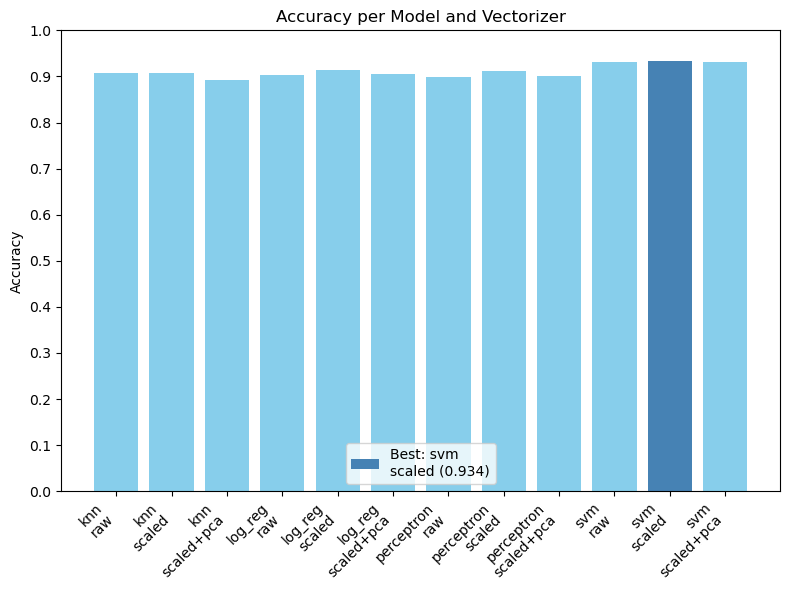

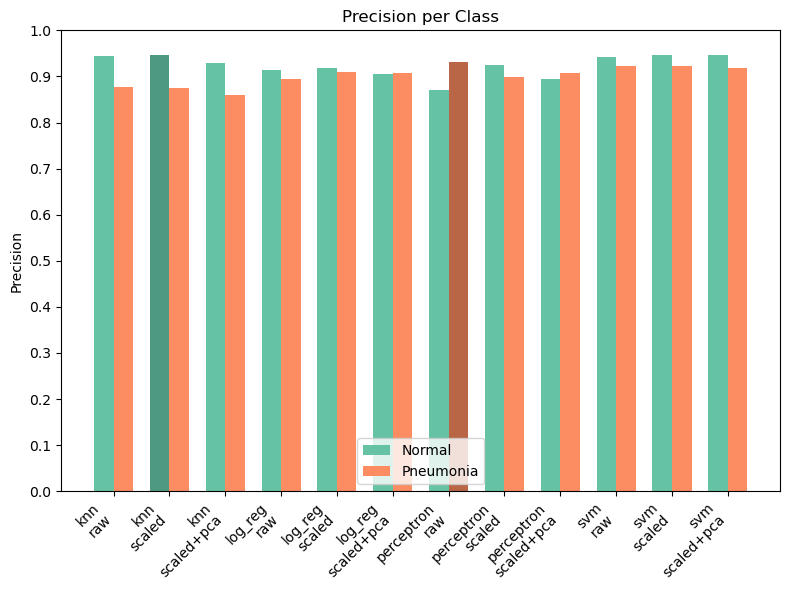

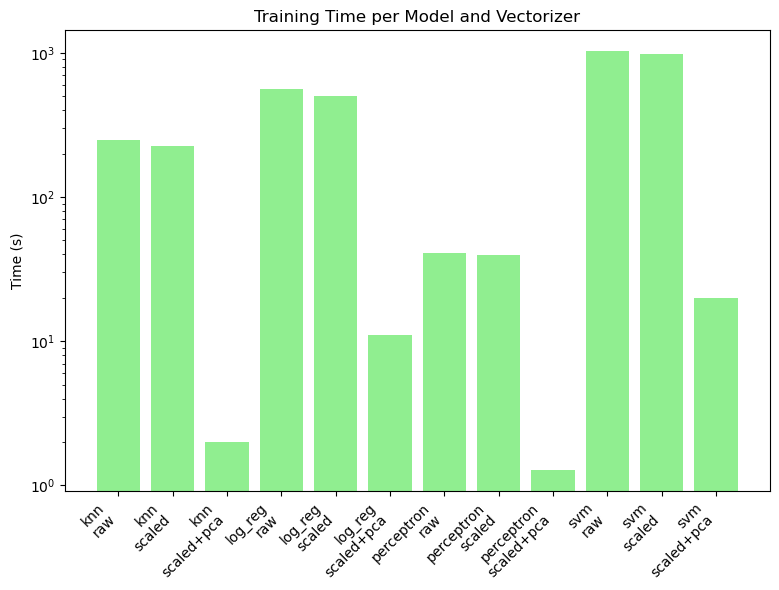

In [90]:
# Graphs
best_results = None
best_results_path = os.path.join(model_folder, "best_results_with_predictions.pkl")
if (os.path.exists(best_results_path)):
    with open(best_results_path, 'rb') as f:
        best_results = pickle.load(f)

model_vec_names = []
accuracies = []
precisions = []
train_times = []

for (model_name, vec_name) in sorted(best_results.keys()):
    info = best_results[(model_name, vec_name)]
    y_pred = info['y_pred']
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=None, zero_division=0)  # Per class precision
    
    model_vec_names.append(f"{model_name}\n{vec_name}")
    accuracies.append(acc)
    precisions.append(prec)
    train_times.append(info.get('time_sec', 0))
        

# Accuracy Figure
plt.figure(figsize=(8, 6))
best_acc_idx = np.argmax(accuracies)  # Find the index of the highest accuracy

# Set the color for the best vectorizer bar to a darker shade
colors = ['#87CEEB' if i != best_acc_idx else '#4682B4' for i in range(len(accuracies))]  # Darker blue for best

bars = plt.bar(model_vec_names, accuracies, color=colors)
plt.title('Accuracy per Model and Vectorizer')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(rotation=45, ha='right')

# Adding custom legend for the best vectorizer
handles, labels = plt.gca().get_legend_handles_labels()
best_label = f"Best: {model_vec_names[best_acc_idx]} ({accuracies[best_acc_idx]})"
plt.legend([bars[best_acc_idx]], [best_label], loc='lower center')

plt.tight_layout()
plt.show()

# Precision Figure (per class)
plt.figure(figsize=(8, 6))
x = np.arange(len(model_vec_names))
width = 0.35
colors = ['#66c2a5', '#fc8d62']  # Normal vs Pneumonia colors
dark_colors = ['#4d9981', '#b86646']
labels = ['Normal', 'Pneumonia']

# Find the best vectorizer for each class and highlight
for i in range(len(categories)):
    class_prec = [p[i] for p in precisions]
    best_prec_idx = np.argmax(class_prec)  # Index of best precision for each class
    bar_colors = [colors[i] if j != best_prec_idx else dark_colors[i] for j in range(len(class_prec))]  # Darker color for best

    plt.bar(x + (i - 0.5) * width, class_prec, width=width, label=labels[i], color=bar_colors)

plt.title('Precision per Class')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(x, model_vec_names, rotation=45, ha='right')
plt.legend(loc='lower center')
plt.tight_layout()
plt.show()

# Training Time Figure
plt.figure(figsize=(8, 6))
plt.bar(model_vec_names, train_times, color='lightgreen')
plt.title('Training Time per Model and Vectorizer')
plt.ylabel('Time (s)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.semilogy()
plt.show()

## Confusion matrix comparison

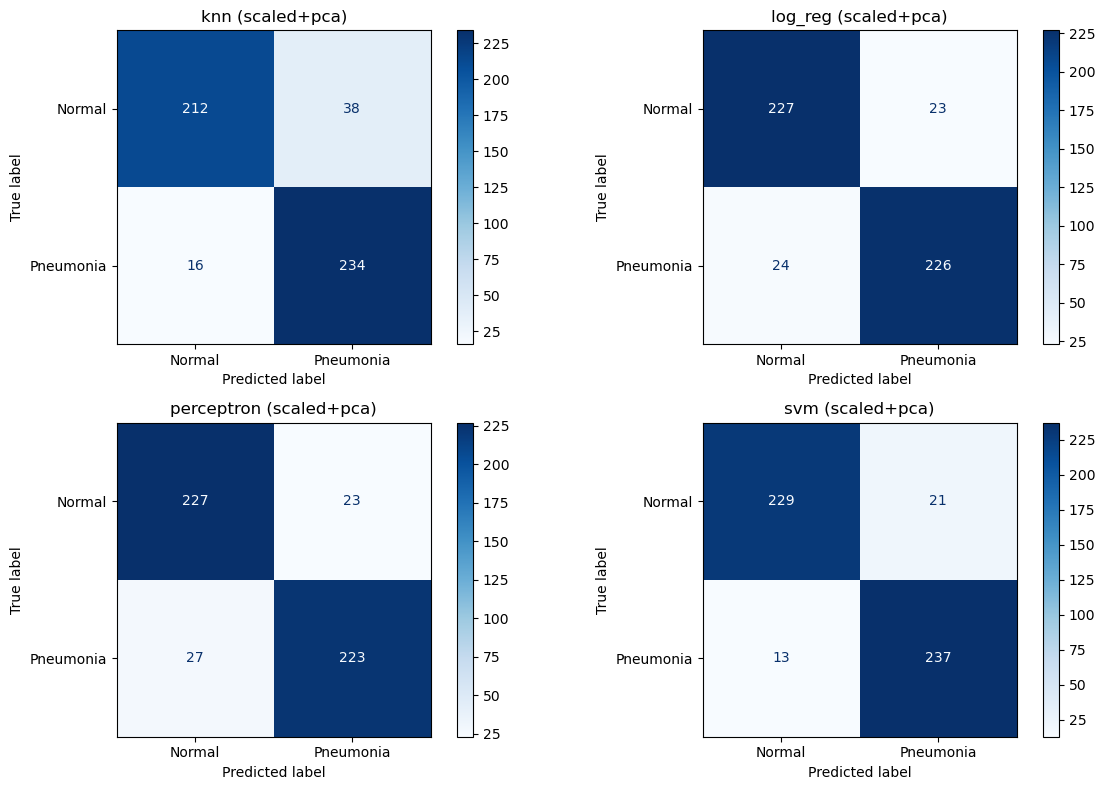

In [54]:
# Filter and loop through all scaled+PCA models
scaled_pca_models = {k: v for k, v in best_results.items() if k[1] == 'scaled+pca'}

# Set up the figure size and number of subplots
num_models = len(scaled_pca_models)
cols = 2  # Set the number of columns for the grid
rows = (num_models + 1) // cols  # Calculate the required number of rows

# Create a figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Flatten to make it easier to index

# Loop through models and plot confusion matrices
for idx, ((model_name, vec_name), info) in enumerate(scaled_pca_models.items()):
    y_pred = info['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
    disp.plot(cmap='Blues', ax=axes[idx])  # Plot to specific axis

    axes[idx].set_title(f'{model_name} ({vec_name})')
    axes[idx].grid(False)

# Remove empty subplots if the number of models is odd
for j in range(num_models, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Comparing the accuracy vs training time

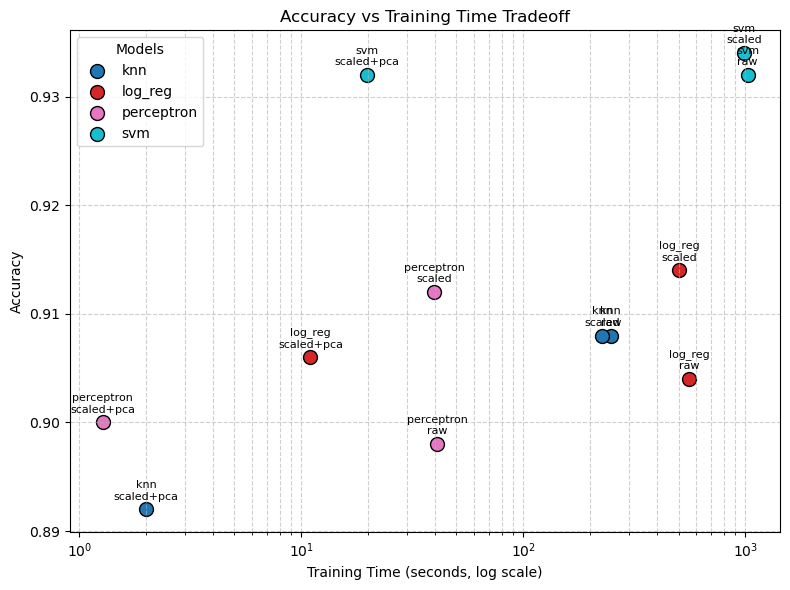

In [91]:
plt.figure(figsize=(8, 6))

# Assign unique colors for each model
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

# Plot each point and color it based on the model key
for i, model_name in enumerate(models.keys()):
    for j, name in enumerate(model_vec_names):
        if model_name in name:
            plt.scatter(
                train_times[j],
                accuracies[j],
                s=100,
                color=colors[i],
                label=model_name if j == model_vec_names.index(f"{model_name}\nraw") else None,
                edgecolor='black'
            )

# Add annotations for each point
for i in range(len(model_vec_names)):
    plt.annotate(
        model_vec_names[i],
        (train_times[i], accuracies[i]),
        textcoords="offset points",
        xytext=(0, 7),
        ha='center',
        fontsize=8
    )

plt.xscale('log')
plt.xlabel('Training Time (seconds, log scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Training Time Tradeoff')
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend(title="Models", loc='best')
plt.tight_layout()
plt.show()
